In [84]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from WFPreprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [85]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")

#Splitting the data into two sets for "old" and "new"
split_idx = len(filtered_time) // 2

# Old data
filtered_time_old = filtered_time.iloc[:split_idx].copy()
data_orig_old = data_orig.iloc[:split_idx].copy()

# New data 
filtered_time_new = filtered_time.iloc[split_idx:].copy()
data_orig_new = data_orig.iloc[split_idx:].copy()

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known= preprocess_data(filtered_time_old, data_orig_old)

0       True
1       True
2       True
3       True
4       True
        ... 
2570    True
2571    True
2572    True
2573    True
2574    True
Name: time_to_next_ev_hr, Length: 2575, dtype: bool
(2464, 3)
Next slips shape (2464, 8)
orig shape (2575, 8)


In [86]:
# Seperating into two subsets, one with 12 hour slips and one with 24 hour slips 

filtered_time_old["interval"] = np.where(
    abs(filtered_time_old["time_to_next_ev_hr"]-12) <= abs(filtered_time_old["time_to_next_ev_hr"]-24), 
    "12h", "24h") 
t_12 = filtered_time_old[filtered_time_old["interval"]=="12h"]
t_24 = filtered_time_old[filtered_time_old["interval"]=="24h"]

print(t_12.head())
print(t_24.head())

   Unnamed: 0          ev_time_utc  time_to_next_ev_hr interval
0           0  2008-01-25 01:50:00           17.354167      12h
2           2  2008-01-26 16:57:15           10.758333      12h
3           3  2008-01-27 03:42:45           13.254167      12h
6           6  2008-01-29 11:03:00           10.487500      12h
7           7  2008-01-29 21:32:15           11.895833      12h
    Unnamed: 0          ev_time_utc  time_to_next_ev_hr interval
1            1  2008-01-25 19:11:15           21.766667      24h
4            4  2008-01-27 16:58:00           19.112500      24h
5            5  2008-01-28 12:04:45           22.970833      24h
22          22  2008-02-06 16:45:30           23.866667      24h
25          25  2008-02-08 17:22:45           21.929167      24h


In [87]:
# Create full-length masked time series
t_12_full = t_12.reindex(data_orig.index)

# Pass full-length objects into preprocessing
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = \
    preprocess_data(t_12_full, data_orig)

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(t_12_full, data_orig)

'''
t_24_full = t_24.reindex(data_orig_old.index)

# Pass full-length objects into preprocessing
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = \
    preprocess_data(t_24_full, data_orig_old)

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(t_24_full, data_orig_old)'''

0       True
1       True
2       True
3       True
4       True
        ... 
5145    True
5146    True
5147    True
5148    True
5149    True
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(5039, 4)
Next slips shape (5039, 8)
orig shape (5150, 8)
0       True
1       True
2       True
3       True
4       True
        ... 
5145    True
5146    True
5147    True
5148    True
5149    True
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(5039, 4)
Next slips shape (5039, 8)
orig shape (5150, 8)


'\nt_24_full = t_24.reindex(data_orig_old.index)\n\n# Pass full-length objects into preprocessing\nX_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known =     preprocess_data(t_24_full, data_orig_old)\n\nX_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(t_24_full, data_orig_old)'

In [88]:
# Running each subset through XGBoost 

#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

#Finding the parameters that minimize the squared error 
optimization = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)) # sampler ensures Optuna gives the same tuning results which gives reproducability between runs 
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-02-19 15:04:18,711] A new study created in memory with name: no-name-bd10cfc0-18ac-4068-a2eb-215d8a75fa5b
[I 2026-02-19 15:04:19,049] Trial 0 finished with value: 5042.811997391686 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 5042.811997391686.
[I 2026-02-19 15:04:19,235] Trial 1 finished with value: 5244.501320259106 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 0 with value: 5042.811997391686.
[I 2026-02-19 15:04:19,578] Trial 2 finished with value: 5068.939661269883 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 0 with value: 5042.811997391686.
[I 2026-02-19 15:04:19,757] Trial 3 finished with value: 5182.473028696728 and para

Optimal Parameters: {'learning_rate': 0.012813252577364058, 'max_depth': 5, 'subsample': 0.7887985998089446, 'colsample_bytree': 0.8157668833374576}
XGBoost Error: 4704.874430789767
Mean XGBoost Error: 3450.2060546875


596     55755.0
1454    52680.0
2417    36930.0
1435    60495.0
480     56805.0
         ...   
377     54915.0
689     35880.0
809     43935.0
1487    32580.0
1465    41445.0
Name: time_to_next_ev_hr, Length: 370, dtype: float64
[58504.75  56817.08  42277.7   57050.49  52243.28  51801.707 50188.125
 50291.188 60575.945 56677.355 58482.668 53638.59  34531.535 37040.836
 34409.117 33990.1   32165.94  50288.918 48403.56  38733.875 53613.242
 40391.977 46680.055 53916.254 30588.85  39948.266 38892.5   44080.652
 52515.098 44011.137 41971.14  61760.785 49971.05  54718.902 52651.96
 40199.098 42219.633 53899.113 48511.883 49818.527 36182.99  60290.01
 50150.375 55178.438 42009.547 55459.96  31239.234 33936.965 56897.31
 52801.965 48162.832 35592.316 38540.875 42209.83  55612.87  54773.773
 50940.58  49272.91  30465.42  48638.82  31313.84  47773.633 56050.516
 40417.492 49768.395 38409.414 47254.11  39480.15  58794.934 50776.34
 35861.062 53855.992 55169.203 30323.373 30828.365 30730.838 479

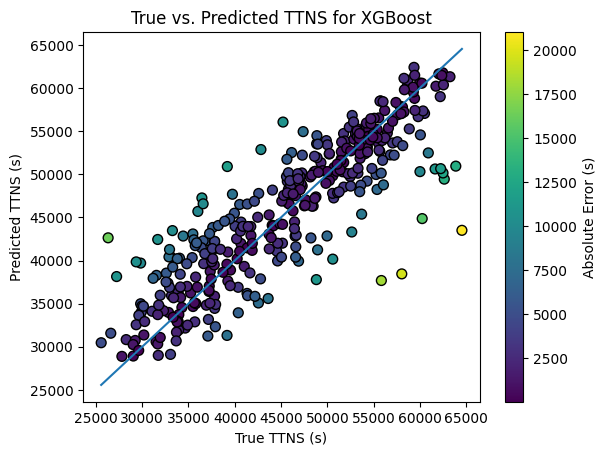

In [89]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
#y_test_secs = y_test.reshape(1,-1)
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction
print(y_test_secs)
print(XG_pred_secs)
absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true}s, Predicted = {pred}s, Error={abs_error}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
plt.show()

In [90]:
# Compute absolute errors
print("Length of Subset", len(XG_pred_secs))
diff = np.abs(XG_pred_secs - y_test_secs)

# Threshold for outliers
threshold = 20000  # adjust as needed

# Get indices of outliers in the test set
X_outliers = np.where(diff > threshold)[0]

print("Number of Outliers", len(X_outliers))
print(f"Outliers (error > {threshold}):")

# Print details for only outliers
for idx in X_outliers:
    true = y_test_secs.iloc[idx]   # pandas Series: use iloc
    pred = XG_pred_secs[idx]       # numpy array: use normal indexing
    print(f"Index position {idx}: True={true}, Predicted={pred}")

Length of Subset 370
Number of Outliers 1
Outliers (error > 20000):
Index position 201: True=64530.0, Predicted=43498.32421875


XG Boost Drivers: time_since     3858.428411
tide_height    1736.315059
tide_deriv     1421.832287
form_fac        778.827290
slip_size       509.942843
high_t_evt      329.381659
dtype: float64


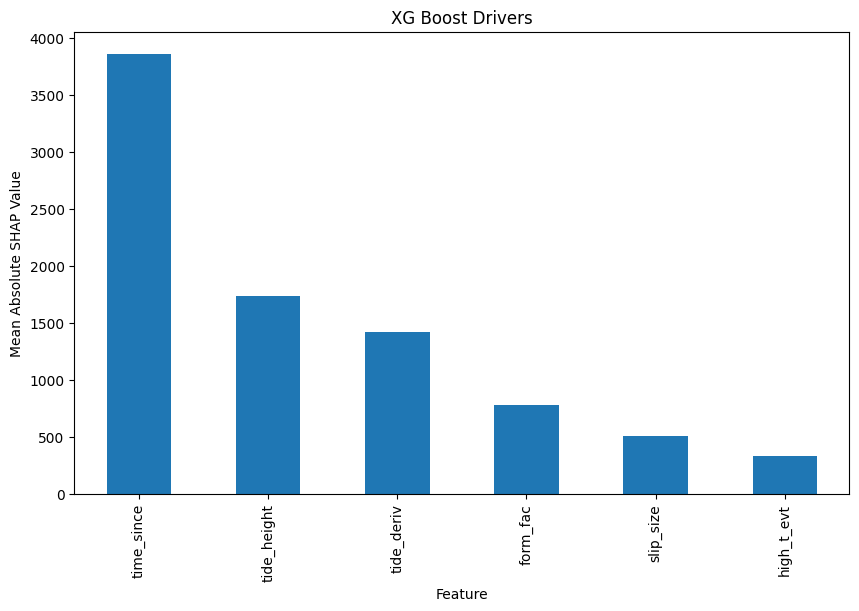

In [91]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
X_shap = pd.DataFrame(X_shap, columns=feature_cols)
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()

In [92]:
#Averaging the value of each feature in the subset so future events can be placed in a subset accordingly 

t_24_features = data_orig_old.loc[t_24.index]
t_12_features = data_orig_old.loc[t_12.index]

feature_cols = [
    "tide_deriv",
    "form_fac",
    "time_since",
    "slip_size",
    "high_t_evt",
    "tide_height"
]

mean_24 = t_24_features[feature_cols].mean()
mean_12 = t_12_features[feature_cols].mean()

print(mean_24)
print(mean_12)




tide_deriv       -0.105725
form_fac          4.264959
time_since     1039.182907
slip_size        -0.020892
high_t_evt        0.803514
tide_height      31.654533
dtype: float64
tide_deriv       -0.158409
form_fac          3.391331
time_since     1175.400411
slip_size        -0.597492
high_t_evt        0.538738
tide_height       1.434387
dtype: float64


In [93]:
#Everything below here should be done with the "new data"

In [94]:


# Checking which subset (12 or 24 each event should fall into):

hr_12feat = np.array([-0.095149, 3.870052, 1186.889497, 0.165857, 0.704595, 32.916218])
hr_24feat = np.array([-0.157254, 2.879485, 1219.971018, -0.410569, 0.537929, 4.149374])

results = []

for idx, row in data_orig_new.iterrows():
    zeros = 0
    ones = 0
    
    # Track which one feature 3 is closer to
    TS_dist12 = abs(row["time_since"] - hr_12feat[2])
    TS_dist24 = abs(row["time_since"] - hr_24feat[2])
    
    # Loop through features
    for i, col in enumerate(feature_cols):
        dist12 = abs(row[col] - hr_12feat[i])
        dist24 = abs(row[col] - hr_24feat[i])
        
        if dist12 <= dist24:
            zeros += 1
        else:
            ones += 1
    
    # Majority decision
    if ones > zeros:
        results.append(1)
    elif zeros > ones:
        results.append(0)
    else:
        # Tie → use feature 3 distance as tiebreaker
        results.append(0 if TS_dist12 <= TS_dist24 else 1)

data_orig_new["final_result"] = results
print(results)

total_ones = (data_orig_new['final_result'] == 1).sum()
total_zeros = (data_orig_new['final_result'] == 0).sum()


print("Total majority 0s:", total_zeros)
print("Total majority 1s:", total_ones)

[1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 

In [95]:
# Assigning feature weights based on whether it looks like 12 or 24 hours 

data_weighted = data_orig_new.copy()

#Should I have left high tide event unscaled?
weights_12 = np.array([10.64, 10.46, 11.16, 9.06,1,18.79])
weights_24 = np.array([14.21,7.78,38.85,5.09,1,17.36])

for idx, row in data_weighted.iterrows():
    
    if row["final_result"] == 1:
        weights = weights_24
    else:
        weights = weights_12
    
    for i, col in enumerate(feature_cols):
        data_weighted.at[idx, col] = row[col] * weights[i]


print(data_weighted.shape)
print(data_weighted[feature_cols].head())
print(data_orig_old.shape)
print(data_orig_old[feature_cols].head())

print(np.allclose(data_orig_old[feature_cols], data_weighted[feature_cols]))


(2575, 9)
      tide_deriv   form_fac  time_since  slip_size  high_t_evt  tide_height
2575   -3.700305  15.682933   22766.100  -6.046503           0  -766.600309
2576   -1.850831  21.085280    9167.940  -4.237381           1   673.163220
2577   -4.816892  13.470944   23989.875  -4.968754           0  -524.833728
2578   -2.280057  18.111321    9541.800  -5.332976           1   723.565241
2579   -5.317679  12.545670   25058.250  -6.843949           0  -646.005651
(2575, 8)
   tide_deriv  form_fac  time_since  slip_size  high_t_evt  tide_height
0   -0.268681  1.826057         NaN  -3.054164           0   -81.877624
1    0.056003  1.826057     1032.50  -1.811724           1    33.714046
2   -0.032735  1.560612     1302.75  -1.110816           1     5.033164
3   -0.056060  1.590570      650.25  -2.703974           0   -35.730665
4   -0.121354  1.590570      797.50  -1.704758           0    -3.994414
False


In [96]:
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time_new, data_weighted)

2575     True
2576     True
2577     True
2578     True
2579     True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 2575, dtype: bool
(2429, 3)
Next slips shape (2429, 9)
orig shape (2575, 9)


In [97]:
# Running each subset through XGBoost 

#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

#Finding the parameters that minimize the squared error 
optimization = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)) # sampler ensures Optuna gives the same tuning results which gives reproducability between runs 
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-02-19 15:04:36,286] A new study created in memory with name: no-name-e590b624-8d30-4987-9963-9c3d6b32c9a5
[I 2026-02-19 15:04:36,649] Trial 0 finished with value: 19582.358129057153 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 19582.358129057153.
[I 2026-02-19 15:04:36,863] Trial 1 finished with value: 19038.632920502045 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 1 with value: 19038.632920502045.
[I 2026-02-19 15:04:37,184] Trial 2 finished with value: 20111.26310593833 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 1 with value: 19038.632920502045.
[I 2026-02-19 15:04:37,446] Trial 3 finished with value: 19728.153414799744 an

Optimal Parameters: {'learning_rate': 0.014129775775162515, 'max_depth': 2, 'subsample': 0.7245961479806006, 'colsample_bytree': 0.816728802893998}
XGBoost Error: 18122.67216992651
Mean XGBoost Error: 14605.30865001286


3285    67800.0
4003    43440.0
4170    54300.0
4147    89565.0
4560    92460.0
         ...   
2653    43665.0
2767    68010.0
4119    89985.0
2783    92280.0
2780    65445.0
Name: time_to_next_ev_hr, Length: 486, dtype: float64
[61411.56  55485.285 49646.375 79791.94  67533.195 54706.04  52678.824
 54527.234 63344.81  55183.992 79945.4   72976.336 78004.58  62519.324
 62490.08  65301.816 65626.56  56470.83  77201.836 75555.99  50920.64
 63004.133 61103.47  59698.8   65784.445 69101.945 59986.77  56445.246
 61755.02  72741.47  77603.14  68607.266 75640.86  63263.094 78137.71
 69511.734 62754.074 55920.227 64806.57  55200.93  61939.305 60569.055
 62958.227 67622.38  50288.87  61492.047 71597.1   56858.895 67990.57
 61558.58  54148.477 52006.508 60276.004 61265.36  61434.465 81085.61
 70135.41  51230.06  74572.18  53813.465 50613.754 77990.08  61787.465
 55418.336 72268.28  47447.4   53659.73  53520.41  66759.48  75660.41
 62649.14  65200.395 58158.71  66312.1   55805.184 78451.92  6555

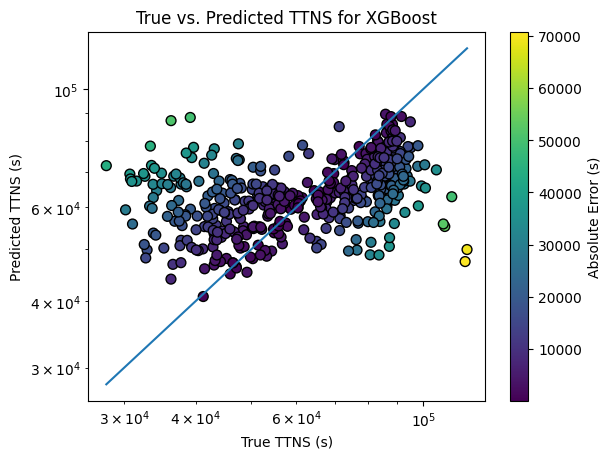

In [98]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
#y_test_secs = y_test.reshape(1,-1)
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction
print(y_test_secs)
print(XG_pred_secs)
absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true}s, Predicted = {pred}s, Error={abs_error}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
plt.xscale('log')
plt.yscale('log')
plt.show()

XG Boost Drivers: tide_height    5024.562156
slip_size      3804.164685
form_fac       3721.873840
time_since     2948.361627
tide_deriv     1987.446691
high_t_evt      552.148833
dtype: float64


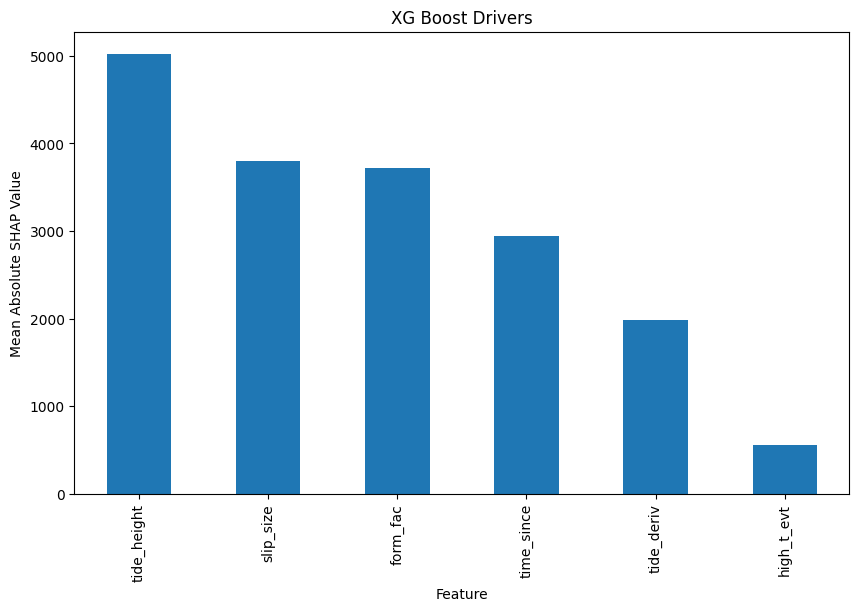

In [99]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
X_shap = pd.DataFrame(X_shap, columns=feature_cols)
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()